In [49]:
import os #import os builtin libarary to work with folders/file paths
import numpy as np #used for numerical operations and arrays

#relative path
data_path='dataset'

#gather all folders/filenames in path under a list
categories=os.listdir(data_path) #return the names of all folders and files
print(categories)

['a', 'ae', 'e', 'u']


In [50]:
#create list of numbers based on the number of categories
labels = [i for i in range(len(categories))]
print(labels)
#maps category names to a number since ml algorithms normaly works with numerical labels
category_dict={'a':0,'ae':1,'e':2,'u':3}
print(category_dict)

[0, 1, 2, 3]
{'a': 0, 'ae': 1, 'e': 2, 'u': 3}


In [51]:
#pip install opencv-python

In [52]:
#import opencv - open source computer vision library for image processing tssk
import cv2

#primary target in application
    #1.read all iamges
    #2.convert them as grayscale (0-255 one channel) and avoid BGR(bcz (0-255*3) 3 channels)
    #target is to reduce the amount of data to process and simpler task
    #3.resize the images

#empty lists for stote processed images and class lable for each image
data=[]
target=[]

#loop through categories
for category in categories:
    #create a new path besed on 
    imgs_path=os.path.join(data_path,category)
    #print(imgs_path)
    print('......')
    img_names=os.listdir(imgs_path)
    #print(img_names)

    #loop through every image inside current category folder
    for img_name in img_names:
        #creates the complete path to the current image
        img_path=os.path.join(imgs_path,img_name)
        print(img_path)

        #read the image from specific path + read it as the grayscale image
        img=cv2.imread(img_path,0)
        #if opencv cant read continue
        if img is None:
            print("Could not read:", img_path)
            continue
        #since original images have doifferent sizes, changes every images to 8*8 pixels
        img=cv2.resize(img,(8,8))
        #cv2.imshow('LIVE',img)
        #k=cv2.waitKey(100)
        #if(k==27):
            #break
#cv2.destroyAllwindows()

        #store both processed 8*8 image to the data list + numerical label in current category
        data.append(img)
        target.append(category_dict[category])

......
dataset\a\0.jpg
dataset\a\1.jpg
dataset\a\1.png
dataset\a\10.jpg
dataset\a\10.png
dataset\a\11.png
dataset\a\12.png
dataset\a\13.png
dataset\a\14.png
dataset\a\15.png
dataset\a\16.png
dataset\a\17.png
dataset\a\18.png
dataset\a\19.png
dataset\a\2.jpg
dataset\a\2.png
dataset\a\20.png
dataset\a\21.png
dataset\a\22.png
dataset\a\23.png
dataset\a\24.png
dataset\a\25.png
dataset\a\26.png
dataset\a\27.png
dataset\a\28.png
dataset\a\29.png
dataset\a\3.jpg
dataset\a\3.png
dataset\a\30.png
dataset\a\31.png
dataset\a\32.png
dataset\a\33.png
dataset\a\34.png
dataset\a\35.png
dataset\a\36.png
dataset\a\37.png
dataset\a\38.png
dataset\a\39.png
dataset\a\4.jpg
dataset\a\4.png
dataset\a\40.png
dataset\a\41.png
dataset\a\42.png
dataset\a\43.png
dataset\a\44.png
dataset\a\45.png
dataset\a\46.png
dataset\a\47.png
dataset\a\48.png
dataset\a\49.png
dataset\a\5.jpg
dataset\a\5.png
dataset\a\50.png
dataset\a\51.png
dataset\a\52.png
dataset\a\53.png
dataset\a\54.png
dataset\a\55.png
dataset\a\56.png
d

In [53]:
#number of images + targets
print(len(data),len(target))

270 270


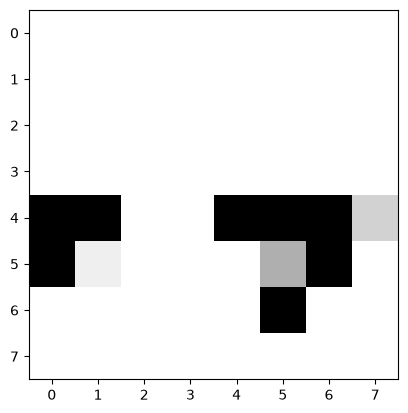

In [54]:
#im port matplotlib's pyplot module
#matplotlib used to display images and graphs
from matplotlib import pyplot as plt
plt.imshow(data[20],cmap='gray') #display using a grayscale color map

In [55]:
data[10]

array([[255, 255, 255, 255, 255, 255, 255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255],
       [  0,   0, 255, 255,   6, 255,   0, 255],
       [255, 255, 255,   0,   0,   0,   0, 255],
       [255, 255,  95, 255, 255,   0, 255,  46],
       [255, 255, 255, 255, 255,   0, 255, 255],
       [255, 255, 255, 255, 255,   0, 255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255]], dtype=uint8)

In [56]:
target[10]

0

In [57]:
#converts the python list containing images into a numpy array
data=np.array(data)
print('before resize:', data.shape) #8*8 images 270

before resize: (270, 8, 8)


In [58]:
#converts the target list nto a numpy array
target=np.array(target)
print('before resize:', target.shape) #number of targets related to images 270

before resize: (270,)


In [59]:
#convert in to 1D - covert every 8*8 images into a one dimensional array
#now every images is represented by one row containing 64 pixel values
data=np.array(data)
print('before resize:', data.shape)
data=data.reshape(data.shape[0],data.shape[1]*data.shape[2])
#data=data.reshape(270,9*8)
print('after resize:', data.shape)
target=np.array(target)

#save the processed data + targets inot relevent .npy files
#.npy format is numpy's binary file format
np.save('data',data)
np.save('target',target)

before resize: (270, 8, 8)
after resize: (270, 64)


In [60]:
print(target.shape)

(270,)


In [61]:
print(target) 

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3]
